In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
dataset_path = r"E:\medical_report_cnn\chest\chest_xray"
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")
val_path = os.path.join(dataset_path, "val")

In [4]:
train_datagen=ImageDataGenerator(rescale=1./255,rotation_range=20,zoom_range=0.2, shear_range=0.2,horizontal_flip=True,fill_mode="nearest")
test_datagen=ImageDataGenerator(rescale=1./255)

In [6]:
train_generator=train_datagen.flow_from_directory(train_path,target_size=(224,224),batch_size=32,class_mode="binary")
validation_generator=test_datagen.flow_from_directory(val_path,target_size=(224,224),batch_size=32,class_mode="binary")
test_generator=test_datagen.flow_from_directory(test_path,target_size=(224,224),batch_size=32,class_mode="binary")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [7]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


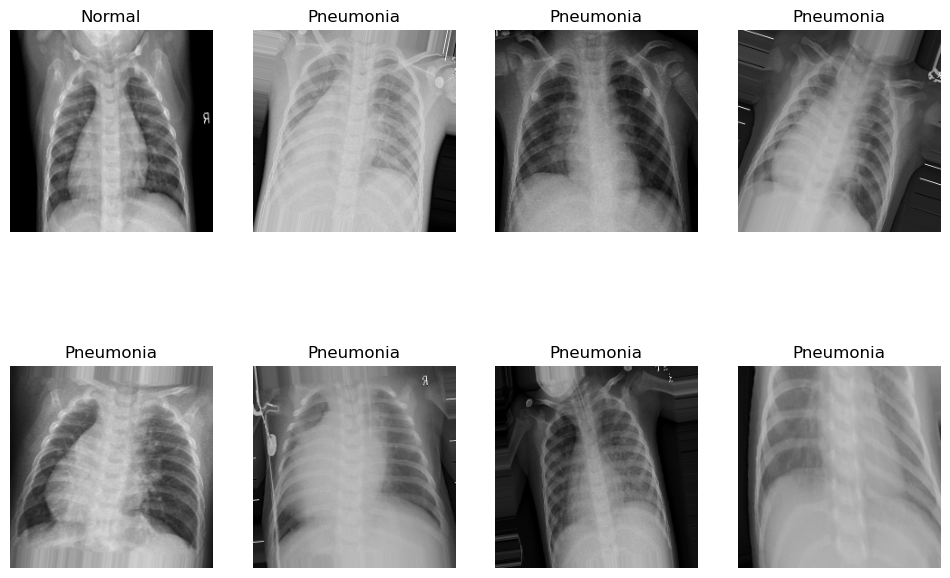

In [10]:
images,labels=next(train_generator)
plt.figure(figsize=(12,8))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i]==1 else "Normal")
    plt.axis("off")
plt.show()

In [11]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))
model.summary()

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       9,437,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,860,801 (37.62 MB)

 Trainable params: 9,859,841 (37.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint("best_chest_model.keras",save_best_only=True)

In [14]:
history = model.fit(train_generator,validation_data=validation_generator,epochs=20,callbacks=[early_stop, checkpoint])

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 632s 4s/step - accuracy: 0.8238 - loss: 1.3167 - val_accuracy: 0.5000 - val_loss: 17.3632
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 504s 3s/step - accuracy: 0.8654 - loss: 0.4396 - val_accuracy: 0.5000 - val_loss: 115.0341
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 666s 4s/step - accuracy: 0.8844 - loss: 0.3316 - val_accuracy: 0.5000 - val_loss: 19.3369
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 700s 4s/step - accuracy: 0.8802 - loss: 0.2934 - val_accuracy: 0.5000 - val_loss: 3.4502
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 855s 5s/step - accuracy: 0.8892 - loss: 0.2955 - val_accuracy: 0.7500 - val_loss: 0.5730
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 718s 4s/step - accuracy: 0.8921 - loss: 0.2812 - val_accuracy: 0.5000 - val_loss: 9.0809
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 562s 3s/step - accuracy: 0.9032 - loss: 0.2643 - val_accuracy: 0.7500 - val_loss: 0.6151
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 494s 3s/step - accuracy: 0.9199 - loss: 0.2160 - val_

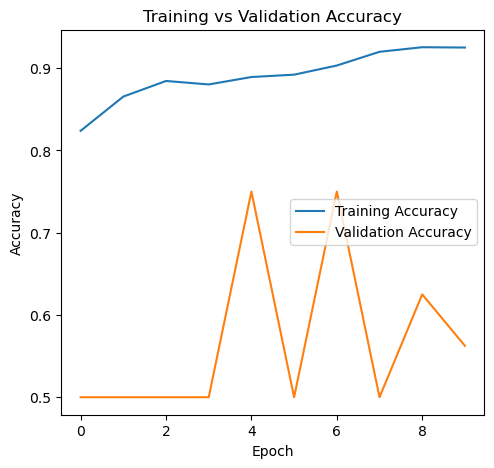

In [15]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

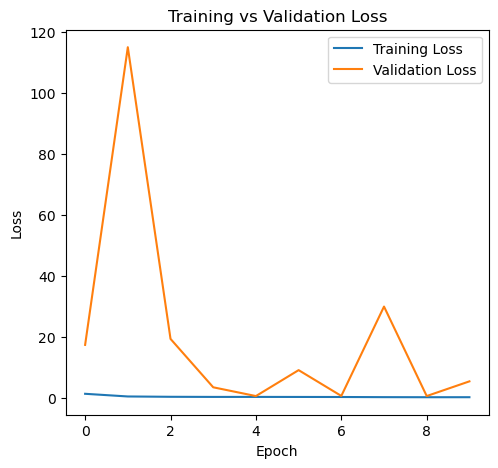

In [16]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [17]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss : {loss:.4f}")
print(f"Test Accuracy : {accuracy*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 846ms/step - accuracy: 0.8429 - loss: 0.4721
Test Loss : 0.4721
Test Accuracy : 84.29%


In [18]:
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step


In [19]:
model.save("chest_xray_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


In [20]:
loaded_model = tf.keras.models.load_model("chest_xray_model.keras")

In [28]:
from tensorflow.keras.preprocessing import image
img_path = r"E:\medical_report_cnn\chest\chest_xray\test\NORMAL\IM-0001-0001.jpeg"
img = image.load_img(img_path,target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array,axis=0)
prediction = loaded_model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


Normal
Confidence: 87.69%


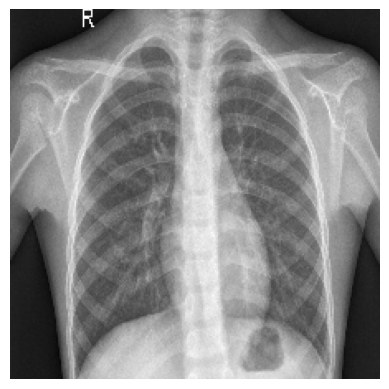

In [30]:
if prediction[0][0] > 0.5:
    print("Pneumonia")
    print(f"Confidence: {prediction[0][0] * 100:.2f}%")
else:
    print("Normal")
    print(f"Confidence: {(1 - prediction[0][0]) * 100:.2f}%")

plt.imshow(img)
plt.axis("off")
plt.show()